# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

# Loading and Determining Population

In [3]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['AggregatedPop1027', 'meuse', 'RegularPop1000', 'cluster', 'random', 'swiss', 'grid'])
dict_keys(['AggregatedPop1027', 'meuse', 'RegularPop1000', 'cluster', 'random', 'swiss', 'grid'])
dict_keys(['unequal', 'equal'])


In [4]:
n = 4
coords = coords_dict['random']
probs = probs_dict['random']['unequal']
N = len(probs)
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

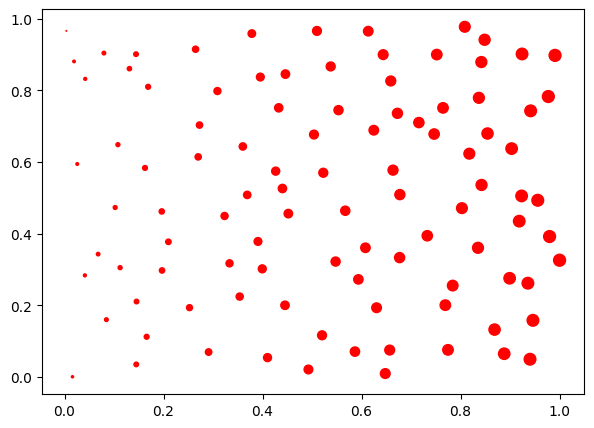

In [5]:
import matplotlib.pyplot as plt
x = coords[:, 0]
y = coords[:, 1]

plt.figure(figsize=(7,5))
plt.scatter(x, y, s=1000*modified_probs, color = 'red')
plt.show()

# Building Initial Designs

In [6]:
orders = [
    # "lexico-yx",
    # "lexico-xy",
    # "random",
    # "angle_0",
    # "distance_0",
    # "projection",
    # "center",
    "spiral",
    # "max",
    # "snake",
    # "hilbert",
]

In [7]:
initial_designs = []
combines = list(itertools.product(orders, orders))
num_trials = 2
for units_order, zones_order in tqdm(combines, desc="Generating initial designs", total=len(combines), unit="orders"):
    best = None
    best_score = np.inf
    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,
            n_zones=(2, 2),
            zone_builder='sweep',
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))

    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,
            n_zones=(1, 1),
            zone_builder='sweep',
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))


Generating initial designs:   0%|          | 0/1 [00:00<?, ?orders/s]

Generating initial designs: 100%|██████████| 1/1 [00:07<00:00,  7.31s/orders]


In [8]:
for design in initial_designs:
    print(design.kmeans.all_samples.shape, design.kmeans.expected_moran_score())

(111, 4) -0.2537789679101993
(111, 4) -0.2537789679101993


# Run Astar

In [9]:
moran_criteria = gs.criteria.MoranCriteria()

In [10]:
astar = gs.search.AStar(
    initial_designs,
    moran_criteria
)

best initial criteria value -0.2537789679101993


In [13]:
import time

t0 = time.perf_counter()
astar.run(
    max_iterations=200,
    num_new_nodes=10,
    max_open_set_size=1000,
    n_clusters_to_change_order_zone=1,
    n_changes_in_order_of_zones=1,
    n_clusters_to_change_order_units=1,
    n_zones_to_change_order_units=1,
    n_changes_in_order_of_units=1,
    n_jobs=-1,
)
elapsed_astar = time.perf_counter() - t0
print(f"A* time: {elapsed_astar:.2f} seconds")


parent node: -0.2537789679101993
iteration: 0, child node: -0.25598624687558424
iteration: 0, child node: -0.24442394003501056
iteration: 0, child node: -0.23811775952043535
iteration: 0, child node: -0.2501789671713986
iteration: 0, child node: -0.2549555677734951
iteration: 0, child node: -0.22804891732908317
iteration: 0, child node: -0.22799784893410927
iteration: 0, child node: -0.23687575478659229
iteration: 0, child node: -0.2518866334633761

parent node: -0.25598624687558424
iteration: 1, child node: -0.2574442561825494
iteration: 1, child node: -0.30419735297440087
iteration: 1, child node: -0.19680256593078385
iteration: 1, child node: -0.22611124335110966
iteration: 1, child node: -0.19765564285518206
iteration: 1, child node: -0.25603672705440833
iteration: 1, child node: -0.2571939842478032
iteration: 1, child node: -0.2518974469864252
iteration: 1, child node: -0.25648965367550675
iteration: 1, child node: -0.18858599463281628

parent node: -0.30419735297440087
iteration

In [14]:
astar.best_criteria_value

-0.33484336531315556

In [15]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,-0.091280,0.224392
moran,-0.334843,0.097481
local_balance,0.732705,1.814465
voronoi,0.126583,0.081862


In [16]:
np.mean(np.abs(astar.best_design.kmeans.fips - modified_probs))

np.float64(4.3071099529827517e-13)

In [17]:
astar.best_design.kmeans.all_samples_probs.sum()

np.float64(0.999999999995)

# Run Bees

In [18]:
bee = gs.search.Bees(
    initial_designs,
    gs.criteria.MoranCriteria(),
    colony_size=20,
    limit=200,
)

Evaluating initial designs...
ABC initialized - Best initial criteria value: -0.2537789679101993


In [20]:
bee.run(
    max_iterations = 1_000,

    n_clusters_to_change_order_zone = 1,
    n_changes_in_order_of_zones = 1,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1,

    max_time_seconds=elapsed_astar * 100
)


Starting ABC with 20 food sources
Colony size: 20, Limit: 200

Iteration 1/1000
  Best: -0.278789, Avg: -0.241094

Iteration 2/1000
  Best: -0.278789, Avg: -0.241880

Iteration 3/1000
  Best: -0.278789, Avg: -0.244117

Iteration 4/1000
  Best: -0.278789, Avg: -0.248979

Iteration 5/1000
  Best: -0.278789, Avg: -0.252294

Iteration 6/1000
NEW BEST at iteration 6
Criteria value: -0.28410084
  Best: -0.284101, Avg: -0.256115

Iteration 7/1000
  Best: -0.284101, Avg: -0.257480

Iteration 8/1000
  Best: -0.284101, Avg: -0.258527

Iteration 9/1000
  Best: -0.284101, Avg: -0.259141

Iteration 10/1000
  Best: -0.284101, Avg: -0.261690

Iteration 11/1000
NEW BEST at iteration 11
Criteria value: -0.28580093
  Best: -0.285801, Avg: -0.263104

Iteration 12/1000
  Best: -0.285801, Avg: -0.263982

Iteration 13/1000
NEW BEST at iteration 13
Criteria value: -0.30553091
  Best: -0.305531, Avg: -0.266603

Iteration 14/1000
  Best: -0.305531, Avg: -0.268802

Iteration 15/1000
NEW BEST at iteration 15
Cr

975